# Protein-Class Specific Enrichment Analysis

Computes odds ratios (ORs) for 103 structural/functional features comparing pathogenic case variants to benign/population control variants, stratified by PANTHER protein class.

**Features (103 total):**
- Secondary structure (9)
- Relative solvent accessibility (5)
- AlphaFold pLDDT (4)
- Intra-protein interactions (4)
- AA physicochemical change (36)
- Reference AA class (6)
- Grantham distance (4)
- UniProt functional sites (5)
- UniProt domain/region annotations (16)
- Post-translational modifications (10)
- Inter-protein interactions (4)

**Output:** Excel spreadsheet with one sheet per metric (OR, CI_lo, CI_up, p_value, q_value), rows = features

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import false_discovery_control
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
DATA_DIR   = '../data'
OUTPUT_DIR = '../results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. Load Data

In [3]:
df_case = pd.read_csv(f'{DATA_DIR}/case_annotation.tsv', sep='\t', low_memory=False)
df_ctrl = pd.read_csv(f'{DATA_DIR}/control_annotation.tsv', sep='\t', low_memory=False)
# df_ctrl = pd.read_csv('/media/drive2/seulki/Project/Missense_2025/data/variant-2025Q4/final_control_annotation_score_vep.txt', sep='\t', low_memory=False)
print(f"Case variants  : {len(df_case):>8,}")
print(f"Control variants: {len(df_ctrl):>7,}")
print(f"\nCase columns   : {list(df_case.columns)}")
print(f"\nControl columns: {list(df_ctrl.columns)}")

Case variants  :   85,321
Control variants: 130,832

Case columns   : ['Gene', 'UniProt', 'UniProt_Isoform', 'Type', 'ResID', 'RefAA', 'AltAA', 'Source', 'Transcript', 'Change_nucleotide', 'Phenotype', 'CS_Confidence', 'protein_class', 'phys_ref', 'AApchem', 'AAdistance', 'ss3', 'ss9', 'plddt', 'phi', 'psi', 'asa', 'rsa', 'Active site', 'Binding site', 'Site', 'DNA binding', 'Zinc finger', 'Region', 'Region/Disordered', 'Region/Interaction', 'Region/Others', 'Motif', 'Coiled coil', 'Compositional bias', 'Repeat', 'Domain', 'Topological domain', 'Transmembrane', 'Intramembrane', 'Signal peptide', 'Transit peptide', 'Propeptide', 'Peptide', 'Chain', 'Lipidation', 'Glycosylation', 'Crosslinks', 'Modified residue', 'Acetylation', 'Methylation', 'Phosphorylation', 'SUMOylation', 'Ubiquitination', 'O-GalNAc/GlcNAc', 'HB_intra', 'SB_intra', 'DS_intra', 'NB_intra', 'HB_inter', 'SB_inter', 'DS_inter', 'NB_inter']

Control columns: ['Gene', 'UniProt', 'UniProt_Isoform', 'Type', 'ResID', 'RefAA',

## 3. Preprocess

- Standardize `protein_class` strings (spaces → `_`, `/` → `,`)
- Map `not-available` to `unclassified`
- Merge any class with < `MIN_CLASS_SIZE` variants in either case or control into `unclassified`

In [4]:
MIN_CLASS_SIZE = 300

def standardize_protein_class(df):
    df = df.copy()
    df['protein_class'] = (
        df['protein_class']
        .str.replace(' ', '_', regex=False)
        .str.replace('/', ',', regex=False)
    )
    df['protein_class'] = df['protein_class'].replace('not-available', 'unclassified')
    return df

df_case = standardize_protein_class(df_case)
df_ctrl = standardize_protein_class(df_ctrl)

In [5]:
all_classes = (
    set(df_case['protein_class'].unique()) |
    set(df_ctrl['protein_class'].unique())
)
all_classes.discard('unclassified')

valid_classes  = []
merged_classes = []

print(f"{'Protein class':<55} {'Case':>7}  {'Ctrl':>7}  {'Total':>7} Status")
print('-' * 85)

for pc in sorted(all_classes):
    n_case = (df_case['protein_class'] == pc).sum()
    n_ctrl = (df_ctrl['protein_class'] == pc).sum()
    n_total = n_case + n_ctrl
    if n_case >= MIN_CLASS_SIZE and n_ctrl >= MIN_CLASS_SIZE:
        valid_classes.append(pc)
        status = 'keep'
    else:
        merged_classes.append(pc)
        df_case['protein_class'] = df_case['protein_class'].replace(pc, 'unclassified')
        df_ctrl['protein_class'] = df_ctrl['protein_class'].replace(pc, 'unclassified')
        status = f'→ unclassified'
    print(f"  {pc:<53} {n_case:>7,}  {n_ctrl:>7,}  {n_total:>7,} {status}")

valid_classes.append('unclassified')
print(f"\nValid classes ({len(valid_classes)}): {valid_classes}")

Protein class                                              Case     Ctrl    Total Status
-------------------------------------------------------------------------------------
  DNA_metabolism_protein                                  1,765    2,976    4,741 keep
  RNA_metabolism_protein                                  1,313    3,927    5,240 keep
  calcium-binding_protein                                   103      330      433 → unclassified
  cell_adhesion_molecule                                  1,403    3,935    5,338 keep
  cell_junction_protein                                     872      204    1,076 → unclassified
  chaperone                                                 284      669      953 → unclassified
  chromatin,chromatin-binding,_or_-regulatory_protein     1,630    4,224    5,854 keep
  cytoskeletal_protein                                    4,814    7,908   12,722 keep
  defense,immunity_protein                                  420    2,688    3,108 keep
  extracellu

In [6]:
# Summary of final class sizes
summary_rows = []
for pc in valid_classes:
    n_case = (df_case['protein_class'] == pc).sum()
    n_ctrl = (df_ctrl['protein_class'] == pc).sum()
    summary_rows.append({'protein_class': pc, 'n_case': n_case, 'n_ctrl': n_ctrl})

df_class_summary = pd.DataFrame(summary_rows).set_index('protein_class')
df_class_summary

,n_case,n_ctrl
protein_class,,
DNA_metabolism_protein,1765,2976
RNA_metabolism_protein,1313,3927
cell_adhesion_molecule,1403,3935
"chromatin,chromatin-binding,_or_-regulatory_protein",1630,4224
cytoskeletal_protein,4814,7908
"defense,immunity_protein",420,2688
extracellular_matrix_protein,6877,4490
gene-specific_transcriptional_regulator,6328,8783
intercellular_signal_molecule,1306,1531


## 4. Feature Definitions

In [7]:
# Secondary structure (9)
SS9_LABELS = ['B', 'E', 'G', 'H', 'I', 'P', 'C', 'S', 'T']
SS9_NAMES  = {
    'B': 'Beta bridge', 'E': 'Beta strand', 'G': '3/10 helix',
    'H': 'Alpha helix', 'I': 'Pi helix',    'P': 'Poly-Pro helix',
    'C': 'Coil',        'S': 'Bend',        'T': 'Turn',
}

# Relative solvent accessibility (5)
RSA_BINS   = [0, 0.05, 0.25, 0.50, 0.75, 1.01]
RSA_LABELS = ['Core', 'Buried', 'Medium-buried', 'Medium-exposed', 'Exposed']

# AlphaFold pLDDT (4)
PLDDT_BINS   = [0, 50, 70, 90, 100.01]
PLDDT_LABELS = ['Very low', 'Low', 'High', 'Very high']

# Intra-protein interactions (4)
PI_FEATURES = [ 'HB_intra', 'SB_intra', 'DS_intra', 'NB_intra'] 

# AA physicochemical classes used in change matrix and reference
PCHEM_CLASSES = [
    'Aliphatic', 'Aromatic', 'Polar/Neutral',
    'Positively-Charged', 'Negatively-Charged', 'Special',
]

# Grantham distance (4)
DIST_BINS   = [0, 50, 100, 150, np.inf]
DIST_LABELS = ['Mild', 'Moderate', 'Substantial', 'Severe']

# UniProt functional sites annotations (5)
FUNCTION_FEATURES = [
    'Active site', 'Binding site', 'Site', 'DNA binding', 'Zinc finger']

# UniProt Domain/Region annotations 
DOMAIN_FEATURES = [
    'Region/Disordered', 'Region/Interaction', 'Region/Others',
    'Motif', 'Coiled coil', 'Compositional bias', 'Repeat', 'Domain',
    'Topological domain', 'Transmembrane', 'Intramembrane',
    'Signal peptide', 'Transit peptide', 'Propeptide', 'Peptide', 'Chain']
    
# Post-translational modifications (6)
PTM_FEATURES = [    
    'Acetylation', 'Methylation', 'Phosphorylation',
    'SUMOylation', 'Ubiquitination', 'O-GalNAc/GlcNAc',
    'Lipidation', 'Glycosylation', 'Crosslinks', 'Modified residue'
]

# Protein-protein interaction contacts (8)
PPI_FEATURES = [
    'HB_inter', 'SB_inter', 'DS_inter', 'NB_inter',
]

N_FEATURES = (
    len(SS9_LABELS) + len(RSA_LABELS) + len(PLDDT_LABELS) + len(PI_FEATURES) +
    len(PCHEM_CLASSES)**2 + len(PCHEM_CLASSES) + len(DIST_LABELS) +
    len(FUNCTION_FEATURES) + len(DOMAIN_FEATURES) + len(PTM_FEATURES) + len(PPI_FEATURES)
)
assert N_FEATURES == 103, f"Expected 103 features, got {N_FEATURES}"
print(f"Total features: {N_FEATURES}")

Total features: 103


## 5. Statistical Functions

In [8]:
def fisher_test(a, b, c, d):
    """
    Fisher's exact test on a 2x2 contingency table.

    Table layout:
                  feature=yes   feature=no
      case group      a              b
      ctrl group      c              d

    Returns
    -------
    odds : float
        Odds ratio  (a*d) / (b*c)
    p_value : float
        Two-sided p-value from Fisher's exact test
    CI_lo, CI_up : float
        95% confidence interval on the OR (Woolf logit method).
        Haldane-Anscombe correction (+0.5) applied when any cell is 0.
    """
    table = np.array([[a, b], [c, d]], dtype=float)
    odds, p_value = stats.fisher_exact(table)

    # CI via Woolf logit; add 0.5 to all cells if any cell is zero
    t = table + 0.5 if np.any(table == 0) else table
    a_, b_, c_, d_ = t.flatten()
    log_or = np.log((a_ * d_) / (b_ * c_))
    se     = np.sqrt(1/a_ + 1/b_ + 1/c_ + 1/d_)
    CI_lo  = np.exp(log_or - 1.96 * se)
    CI_up  = np.exp(log_or + 1.96 * se)

    return odds, p_value, CI_lo, CI_up

In [9]:
def is_present(series):
    """True where annotation is present (not NaN and not '-')."""
    return series.notna() & (series != '-')


def compute_or_features(df_case, df_ctrl):
    """
    Compute OR for all 103 features between case and control DataFrames.

    Returns
    -------
    pd.DataFrame  —  index = feature label, columns = OR, CI_lo, CI_up,
                     p_value, q_value, n_case_yes, n_ctrl_yes
    """
    records = {}
    n_case  = len(df_case)
    n_ctrl  = len(df_ctrl)

    def add(name, n_case, n_ctrl, yes_case, yes_ctrl):
        yes_case = int(yes_case)
        yes_ctrl = int(yes_ctrl)
        if n_case == 0 or n_ctrl == 0 or (yes_case == n_case and yes_ctrl == n_ctrl):
            records[name] = dict(
                OR=np.nan, CI_lo=np.nan, CI_up=np.nan,
                p_value=np.nan, n_case_yes=yes_case, n_ctrl_yes=yes_ctrl,
            )
            return
        or_, p, clo, cup = fisher_test(
            yes_case, n_case - yes_case,
            yes_ctrl, n_ctrl - yes_ctrl,
        )
        records[name] = dict(
            OR=or_, CI_lo=clo, CI_up=cup,
            p_value=p, n_case_yes=yes_case, n_ctrl_yes=yes_ctrl,
        )

    # ── 1. Secondary structure (9) ───────────────────────────────────────────
    for val in SS9_LABELS:
        n_case_ss9 = len(df_case['ss9'].dropna())
        n_ctrl_ss9 = len(df_ctrl['ss9'].dropna())
        add(f'SS:{val}',
            n_case_ss9, n_ctrl_ss9,
            (df_case['ss9'] == val).sum(),
            (df_ctrl['ss9'] == val).sum())

    # ── 2. Relative solvent accessibility (5) ────────────────────────────────
    case_rsa = pd.cut(df_case['rsa'].dropna(), bins=RSA_BINS, labels=RSA_LABELS, include_lowest=True)
    ctrl_rsa = pd.cut(df_ctrl['rsa'].dropna(), bins=RSA_BINS, labels=RSA_LABELS, include_lowest=True)
    n_case_rsa = len(case_rsa)
    n_ctrl_rsa = len(ctrl_rsa)
    for val in RSA_LABELS:
        add(f'RSA:{val}', n_case_rsa, n_ctrl_rsa, (case_rsa == val).sum(), (ctrl_rsa == val).sum())

    # ── 3. AlphaFold pLDDT (4) ───────────────────────────────────────────────
    case_plddt = pd.cut(df_case['plddt'].dropna(), bins=PLDDT_BINS, labels=PLDDT_LABELS, include_lowest=True)
    ctrl_plddt = pd.cut(df_ctrl['plddt'].dropna(), bins=PLDDT_BINS, labels=PLDDT_LABELS, include_lowest=True)
    n_case_plddt = len(case_plddt)
    n_ctrl_plddt = len(ctrl_plddt)
    for val in PLDDT_LABELS:
        add(f'pLDDT:{val}', n_case_plddt, n_ctrl_plddt, (case_plddt == val).sum(), (ctrl_plddt == val).sum())

    # ── 4. AA physicochemical change (36) ────────────────────────────────────
    for ref in PCHEM_CLASSES:
        for alt in PCHEM_CLASSES:
            label = f'{ref}>{alt}'
            add(f'AAchange:{label}',
                n_case, n_ctrl,
                (df_case['AApchem'] == label).sum(),
                (df_ctrl['AApchem'] == label).sum())

    # ── 5. Reference AA physicochemical class (6) ────────────────────────────
    for val in PCHEM_CLASSES:
        add(f'RefAA:{val}',
            n_case, n_ctrl,
            (df_case['phys_ref'] == val).sum(),
            (df_ctrl['phys_ref'] == val).sum())

    # ── 6. Grantham distance (4) ─────────────────────────────────────────────
    case_dist = pd.cut(df_case['AAdistance'], bins=DIST_BINS, labels=DIST_LABELS, include_lowest=True)
    ctrl_dist = pd.cut(df_ctrl['AAdistance'], bins=DIST_BINS, labels=DIST_LABELS, include_lowest=True)
    for val in DIST_LABELS:
        add(f'Grantham:{val}', n_case, n_ctrl, (case_dist == val).sum(), (ctrl_dist == val).sum())

    # ── 7. Intra-protein interactions (4) ────────────────────────────────────
    for feat in PI_FEATURES:
        add(f'PI:{feat}',
            n_case, n_ctrl,
            is_present(df_case[feat]).sum(),
            is_present(df_ctrl[feat]).sum())

    # ── 8. UniProt functional sites (5) ──────────────────────────────────────
    for feat in FUNCTION_FEATURES:
        add(f'Function:{feat}',
            n_case, n_ctrl,
            is_present(df_case[feat]).sum(),
            is_present(df_ctrl[feat]).sum())

    # ── 9. UniProt domain/region annotations (16) ────────────────────────────
    for feat in DOMAIN_FEATURES:
        add(f'Domain:{feat}',
            n_case, n_ctrl,
            is_present(df_case[feat]).sum(),
            is_present(df_ctrl[feat]).sum())

    # ── 10. Post-translational modifications (10) ────────────────────────────
    for feat in PTM_FEATURES:
        add(f'Modification:{feat}',
            n_case, n_ctrl,
            is_present(df_case[feat]).sum(),
            is_present(df_ctrl[feat]).sum())

    # ── 11. Inter-protein interactions (4) ───────────────────────────────────
    for feat in PPI_FEATURES:
        add(f'PPI:{feat}',
            n_case, n_ctrl,
            is_present(df_case[feat]).sum(),
            is_present(df_ctrl[feat]).sum())

    df = pd.DataFrame(records).T
    df.index.name = 'feature'

    # BH FDR correction across all 103 features
    valid_mask = df['p_value'].notna()
    q_values   = np.full(len(df), np.nan)
    if valid_mask.sum() > 0:
        q_values[valid_mask] = false_discovery_control(
            df.loc[valid_mask, 'p_value'].values, method='bh'
        )
    df.insert(df.columns.get_loc('p_value') + 1, 'q_value', q_values)
    return df

## 6. Compute OR — All Case / Control

In [10]:
print(f"Case: {len(df_case):,} variants  |  Control: {len(df_ctrl):,} variants")
or_all = compute_or_features(df_case, df_ctrl)

n_sig = (or_all['q_value'] < 0.01).sum()
print(f"Features computed : {len(or_all)}")
print(f"Significant (q<0.01): {n_sig}")
or_all.head(15)

Case: 85,321 variants  |  Control: 130,832 variants
Features computed : 103
Significant (q<0.01): 100


,OR,CI_lo,CI_up,p_value,q_value,n_case_yes,n_ctrl_yes
feature,,,,,,,
SS:B,2.095935,1.863285,2.357634,1.042035e-35,1.511684e-35,688.0,470.0
SS:E,1.949960,1.896735,2.004679,0.000000e+00,0.000000e+00,13002.0,10362.0
SS:G,1.353493,1.278055,1.433383,6.546386e-25,8.756854e-25,2331.0,2474.0
SS:H,1.673580,1.640216,1.707623,0.000000e+00,0.000000e+00,27537.0,27431.0
SS:I,3.117067,2.723904,3.566979,7.270310e-67,1.291107e-66,674.0,310.0
SS:P,0.896210,0.855153,0.939239,4.558175e-06,4.994596e-06,2971.0,4703.0
SS:C,0.349195,0.341986,0.356556,0.000000e+00,0.000000e+00,16867.0,48755.0
SS:S,1.327706,1.278477,1.378831,1.227488e-48,1.945096e-48,5507.0,6018.0
SS:T,1.182294,1.143246,1.222676,1.943535e-22,2.536131e-22,6752.0,8251.0


## 7. Compute OR — By Protein Class

In [11]:
or_by_class = {}

print(f"{'Protein class':<55} {'Case':>7}  {'Ctrl':>7}  {'Sig(q<0.05)':>11}")
print('-' * 90)

for pc in valid_classes:
    case_pc = df_case[df_case['protein_class'] == pc]
    ctrl_pc = df_ctrl[df_ctrl['protein_class'] == pc]
    or_pc   = compute_or_features(case_pc, ctrl_pc)
    or_by_class[pc] = or_pc
    n_sig = (or_pc['q_value'] < 0.01).sum()
    print(f"  {pc:<53} {len(case_pc):>7,}  {len(ctrl_pc):>7,}  {n_sig:>11}")

print(f"\nDone. {len(or_by_class)} protein classes computed.")

Protein class                                              Case     Ctrl  Sig(q<0.05)
------------------------------------------------------------------------------------------
  DNA_metabolism_protein                                  1,765    2,976           48
  RNA_metabolism_protein                                  1,313    3,927           50
  cell_adhesion_molecule                                  1,403    3,935           58
  chromatin,chromatin-binding,_or_-regulatory_protein     1,630    4,224           59
  cytoskeletal_protein                                    4,814    7,908           71
  defense,immunity_protein                                  420    2,688           35
  extracellular_matrix_protein                            6,877    4,490           70
  gene-specific_transcriptional_regulator                 6,328    8,783           73
  intercellular_signal_molecule                           1,306    1,531           52
  membrane_traffic_protein                       

## 8. Combine Results into Spreadsheets

In [12]:
METRICS       = ['OR', 'p_value', 'q_value', 'n_case_yes', 'n_ctrl_yes']
GROUPS        = ['All'] + valid_classes
feature_index = or_all.index

# One DataFrame per metric: rows = features, columns = [All, PC1, PC2, ...]
result_dfs = {}
for metric in METRICS:
    df_m = pd.DataFrame(index=feature_index)
    df_m['All'] = or_all[metric]
    for pc in valid_classes:
        df_m[pc] = or_by_class[pc][metric]
    result_dfs[metric] = df_m

print("OR table (first 10 features, first 5 columns):")
result_dfs['OR'].iloc[:10, :5].round(3)

OR table (first 10 features, first 5 columns):


,All,DNA_metabolism_protein,RNA_metabolism_protein,cell_adhesion_molecule,"chromatin,chromatin-binding,_or_-regulatory_protein"
feature,,,,,
SS:B,2.096,1.199,2.548,0.937,2.388
SS:E,1.950,2.320,3.177,0.865,5.639
SS:G,1.353,0.925,1.373,1.222,3.250
SS:H,1.674,1.789,1.730,0.980,3.702
SS:I,3.117,1.055,3.728,0.547,5.733
SS:P,0.896,0.432,0.674,1.012,1.078
SS:C,0.349,0.330,0.309,0.698,0.157
SS:S,1.328,1.470,1.762,2.142,2.289
SS:T,1.182,1.179,1.556,1.249,2.830


## 9. Save Results

## Excel sheets for each metric

In [13]:
xlsx_path = f'{OUTPUT_DIR}/enrichment_OR_by_protein_class.xlsx'

with pd.ExcelWriter(xlsx_path, engine='openpyxl') as writer:
    # Metadata sheet
    meta = pd.DataFrame({
        'key': ['n_case_total', 'n_ctrl_total', 'n_features',
                'n_protein_classes', 'min_class_size', 'fdr_method'],
        'value': [len(df_case), len(df_ctrl), N_FEATURES,
                  len(valid_classes), MIN_CLASS_SIZE, 'Benjamini-Hochberg'],
    })
    meta.to_excel(writer, sheet_name='metadata', index=False)

    # Class size sheet
    df_class_summary.to_excel(writer, sheet_name='class_sizes')

    # One sheet per metric
    for metric, df_m in result_dfs.items():
        df_m.to_excel(writer, sheet_name=metric)

print(f"Saved: {xlsx_path}")
print(f"Sheets: metadata, class_sizes, {', '.join(METRICS)}")

Saved: ../results/enrichment_OR_by_protein_class.xlsx
Sheets: metadata, class_sizes, OR, p_value, q_value, n_case_yes, n_ctrl_yes


## Flat CSV with multi-level columns (feature, group, metric)

In [14]:
frames = []
for metric, df_m in result_dfs.items():
    df_m_mi = df_m.copy()
    df_m_mi.columns = pd.MultiIndex.from_tuples(
        [(col, metric) for col in df_m.columns]
    )
    frames.append(df_m_mi)

df_combined = pd.concat(frames, axis=1)
# Reorder columns: group-major, metric-minor
cols_ordered = [
    (grp, metric)
    for grp in GROUPS
    for metric in METRICS
]
df_combined = df_combined[cols_ordered]

# replace group names in the multi-index columns with [x.replace("_"," ").replace(",","/") for x in GROUPS]
new_groups = [x.replace("_", " ").replace(",", "/") for x in GROUPS]
new_columns = []
for col in df_combined.columns:
    group, metric = col
    new_group = group.replace("_", " ").replace(",", "/")
    new_columns.append((new_group, metric))
df_combined.columns = pd.MultiIndex.from_tuples(new_columns)
print("Updated column groups:")
print(df_combined.columns.get_level_values(0).unique())

csv_path = f'{OUTPUT_DIR}/enrichment_OR_by_protein_class.csv'
df_combined.to_csv(csv_path)
print(f"Saved: {csv_path}")
print(f"Shape: {df_combined.shape}  ({df_combined.shape[0]} features × {df_combined.shape[1]} columns)")

Updated column groups:
Index(['All', 'DNA metabolism protein', 'RNA metabolism protein',
       'cell adhesion molecule',
       'chromatin/chromatin-binding/ or -regulatory protein',
       'cytoskeletal protein', 'defense/immunity protein',
       'extracellular matrix protein',
       'gene-specific transcriptional regulator',
       'intercellular signal molecule', 'membrane traffic protein',
       'metabolite interconversion enzyme',
       'protein-binding activity modulator', 'protein modifying enzyme',
       'scaffold/adaptor protein', 'structural protein',
       'transfer/carrier protein', 'translational protein',
       'transmembrane signal receptor', 'transporter', 'unclassified'],
      dtype='object')
Saved: ../results/enrichment_OR_by_protein_class.csv
Shape: (103, 105)  (103 features × 105 columns)


## 10. Heatmap Visualization

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

plt.rcParams['figure.dpi']        = 300
plt.rcParams['font.family']       = 'Arial'
plt.rcParams['font.size']         = 7
plt.rcParams['axes.titlesize']    = 7
plt.rcParams['axes.labelsize']    = 7
plt.rcParams['xtick.labelsize']   = 6
plt.rcParams['ytick.labelsize']   = 6
plt.rcParams['legend.fontsize']   = 6
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['axes.linewidth']    = 0.4
plt.rcParams['xtick.major.width'] = 0.4
plt.rcParams['ytick.major.width'] = 0.4
plt.rcParams['xtick.major.size']  = 2.5
plt.rcParams['ytick.major.size']  = 2.5
plt.rcParams['patch.linewidth']   = 0.4

In [16]:
def replace_inf_with_row_max(row):
    """Replace np.inf with the row's finite maximum."""
    max_val = row.replace([np.inf, -np.inf], np.nan).max()
    return row.replace(np.inf, max_val)


def change_feature_name(feature_list):
    """Map prefixed feature labels to publication-ready display names."""
    _map = {
        # Secondary structure
        'SS:B': '$\\beta$-bridge',     'SS:E': '$\\beta$-sheet',
        'SS:G': '3$_{10}$-helix',      'SS:H': '$\\alpha$-helix',
        'SS:I': '$\\pi$-helix',        'SS:P': 'Poly-Pro helix',
        'SS:C': 'Loop/Coil',           'SS:S': 'Bend',
        'SS:T': 'Turn',
        # RSA
        'RSA:Core':           'Core',
        'RSA:Buried':         'Buried',
        'RSA:Medium-buried':  'Med-buried',
        'RSA:Medium-exposed': 'Med-exposed',
        'RSA:Exposed':        'Exposed',
        # pLDDT
        'pLDDT:Very low':  'pLDDT very low',
        'pLDDT:Low':       'pLDDT low',
        'pLDDT:High':      'pLDDT high',
        'pLDDT:Very high': 'pLDDT very high',
        # Grantham
        'Grantham:Mild':         'Grantham mild',
        'Grantham:Moderate':     'Grantham moderate',
        'Grantham:Substantial':  'Grantham substantial',
        'Grantham:Severe':       'Grantham severe',
        # Intra-protein interactions
        'PI:HB_intra': 'H-bond (intra)',
        'PI:SB_intra': 'Salt bridge (intra)',
        'PI:DS_intra': 'Disulfide (intra)',
        'PI:NB_intra': 'vdW (intra)',
        # Inter-protein interactions
        'PPI:HB_inter': 'H-bond (inter)',
        'PPI:SB_inter': 'Salt bridge (inter)',
        'PPI:DS_inter': 'Disulfide (inter)',
        'PPI:NB_inter': 'vdW (inter)',
    }
    # For prefixed features not in map, strip the prefix
    def _label(f):
        if f in _map:
            return _map[f]
        if ':' in f:
            return f.split(':', 1)[1]
        return f

    return [_label(f) for f in feature_list]

In [17]:
FDR_THRESHOLD = 0.01

# Mask non-significant ORs with NaN, replace inf with row max
df_OR  = result_dfs['OR']
df_Q   = result_dfs['q_value']
df_OR_masked = df_OR.where(df_Q < FDR_THRESHOLD)
df_OR_masked = df_OR_masked.apply(replace_inf_with_row_max, axis=1)

print(f"OR matrix shape: {df_OR_masked.shape}")
print(f"Non-NaN entries : {df_OR_masked.notna().sum().sum()} / {df_OR_masked.size}")

# Feature groups for per-panel plots
FEAT_GROUPS = {
    'Physchem':    [f for f in df_OR_masked.index if f.startswith(('AAchange:', 'RefAA:', 'Grantham:'))],
    'Structure':    [f for f in df_OR_masked.index if f.startswith(('SS:', 'RSA:', 'pLDDT:', "PI:"))],
    'Function': [f for f in df_OR_masked.index if f.startswith(('Function:'))],
    'Domain':   [f for f in df_OR_masked.index if f.startswith(('Domain:'))],
    'Modification':   [f for f in df_OR_masked.index if f.startswith(('Modification:'))],
    'PPI':   [f for f in df_OR_masked.index if f.startswith(('PPI:'))],
}
for g, feats in FEAT_GROUPS.items():
    print(f"  {g}: {len(feats)} features")

OR matrix shape: (103, 21)
Non-NaN entries : 1319 / 2163
  Physchem: 46 features
  Structure: 22 features
  Function: 5 features
  Domain: 16 features
  Modification: 10 features
  PPI: 4 features


In [18]:
def plot_heatmap(df_plot, figsize, title='', annotate=False, cmap='coolwarm',
                 vmin=0.05, vmax=20, save_path=None):
    """
    Heatmap of odds ratios.
    Rows (x-axis) = features, Columns (y-axis) = protein classes / All.
    NaN cells (non-significant) are shown in light grey.
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Grey background for NaN (non-significant) cells
    ax.set_facecolor('#e0e0e0')

    sns.heatmap(
        df_plot.T,
        ax=ax,
        cmap=cmap,
        norm=LogNorm(vmin=vmin, vmax=vmax),
        cbar=True,
        cbar_kws={'shrink': 0.8, 'pad': 0.02, 'label': 'Odds ratio'},
        annot=annotate,
        fmt='.2f',
        annot_kws={'fontsize': 5},
        linewidths=0,
        linecolor='none',
    )

    ax.set_xticklabels(change_feature_name(list(df_plot.index)), rotation=90, ha='center')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xlabel('')
    ax.set_ylabel('')
    if title:
        ax.set_title(title, pad=4)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.4)

    ax.grid(axis='x', linestyle='--', color='black', linewidth=0.1)
    ax.grid(axis='y', linestyle='--', color='black', linewidth=0.1)

    plt.tight_layout()
    # Fix the margin
    plt.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.15)
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

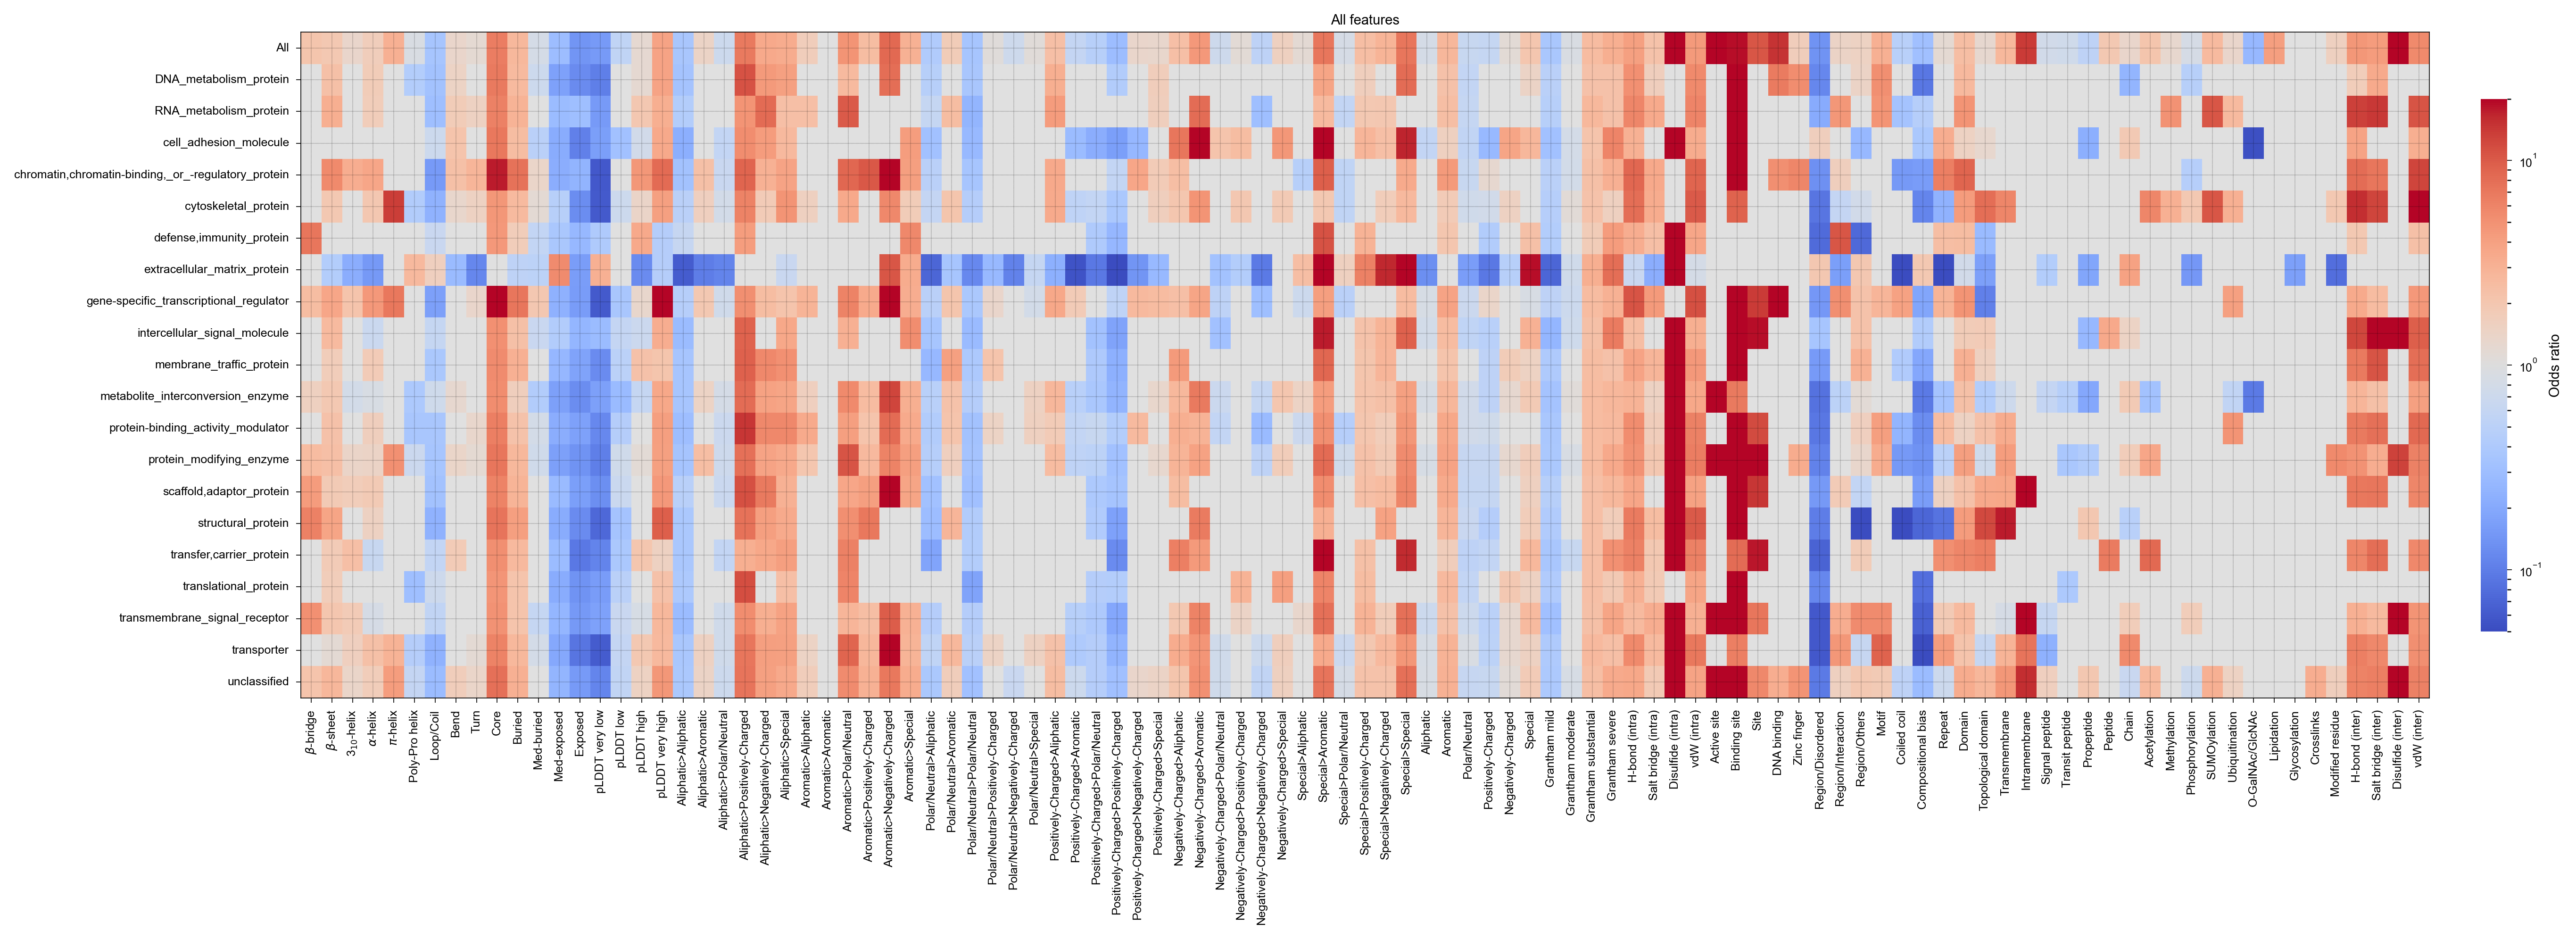

In [19]:
#  Combined heatmap (all 103 features) 
n_classes = len(valid_classes) + 1   # +1 for 'All' column
plot_heatmap(
    df_OR_masked,
    figsize=(103 * 0.22, n_classes * 0.28),
    title='All features',
    annotate=False#,
    # save_path=f'{OUTPUT_DIR}/heatmap_all_features.pdf',
)